# Neural Network Implementation from Scratch

### Generative AI Lab – Practice Assignment 1

**Student Name:** Swapnil Santosh Akhade  
**PRN:** 202401110002  
**Branch:** CSE AIML  
**Batch:** A1

## 2. Problem Definition

### Dataset

The MNIST dataset consists of grayscale images of handwritten digits ranging from 0 to 9. Each image has a resolution of 28 × 28 pixels.

For this experiment, the standard MNIST dataset is used:

- Training samples: 60,000
- Testing samples: 10,000
- Input features per image: 784
- Number of classes: 10

### Task

The task is a multiclass classification problem.

Given an image of a handwritten digit, the neural network must predict the corresponding digit from 0 to 9.

### Input

Each 28 × 28 image is flattened into a vector containing 784 pixel values.

### Output

The network produces 10 output probabilities corresponding to the ten digit classes:

0, 1, 2, 3, 4, 5, 6, 7, 8, 9.

## 3. Methodology

The neural network is implemented using NumPy for numerical computations. No built-in deep learning framework is used for constructing or training the neural network.

The implementation consists of the following stages:

1. Dataset preparation
2. Neural network parameter initialization
3. Forward propagation
4. Loss calculation
5. Backpropagation
6. Gradient descent
7. Mini-batch training
8. Model evaluation

## 4. Neural Network Architecture

The feedforward neural network consists of an input layer, two hidden layers, and an output layer.

| Layer | Number of Neurons | Activation |
|------|-------------------:|------------|
| Input Layer | 784 | None |
| Hidden Layer 1 | 128 | ReLU |
| Hidden Layer 2 | 64 | ReLU |
| Output Layer | 10 | Softmax |

The input layer contains 784 neurons because each 28 × 28 MNIST image is flattened into 784 pixel values.

The output layer contains 10 neurons because the MNIST dataset contains ten digit classes from 0 to 9.

## 5. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 6. Load the MNIST Dataset

### 6.1 Download the dataset from kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


### 6.2 Read the csv files

In [3]:
train_data = pd.read_csv(path + "/mnist_train.csv")
test_data = pd.read_csv(path + "/mnist_test.csv")

print("Training dataset shape:", train_data.shape)
print("Testing dataset shape:", test_data.shape)

Training dataset shape: (60000, 785)
Testing dataset shape: (10000, 785)


### 6.3 Inspect the dataset

In [4]:
print("First 5 rows:")
display(train_data.head())

First 5 rows:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print("Dataset information:")
print(train_data.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None


### 6.4 Check the labels

In [6]:
print("Unique labels:", sorted(train_data.iloc[:, 0].unique()))

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 7. Explore the dataset

### 7.1 Dataset dimensions

In [7]:
print("Training dataset:")
print("Number of samples:", train_data.shape[0])
print("Number of columns:", train_data.shape[1])

print("\nTesting dataset:")
print("Number of samples:", test_data.shape[0])
print("Number of columns:", test_data.shape[1])

Training dataset:
Number of samples: 60000
Number of columns: 785

Testing dataset:
Number of samples: 10000
Number of columns: 785


### 7.2 Check the pixel value range

In [8]:
pixel_values = train_data.iloc[:, 1:]

print("Minimum pixel value:", pixel_values.min().min())
print("Maximum pixel value:", pixel_values.max().max())

Minimum pixel value: 0
Maximum pixel value: 255


### 7.3 Check class distribution

In [9]:
label_counts = train_data.iloc[:, 0].value_counts().sort_index()

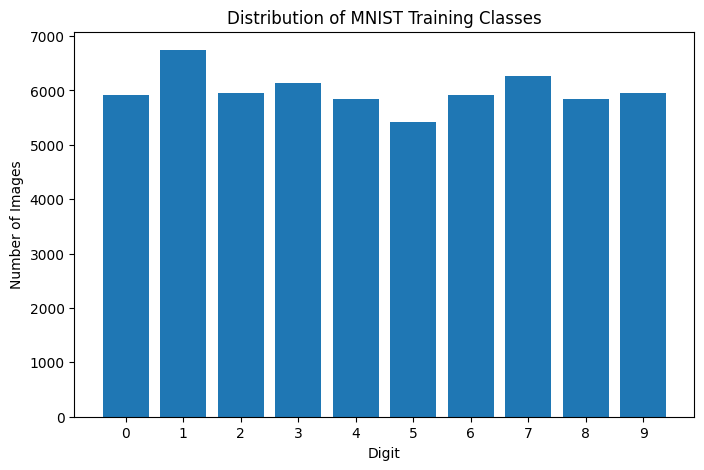

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Distribution of MNIST Training Classes")
plt.xticks(range(10))

plt.show()

### 7.4 Visualize sample images

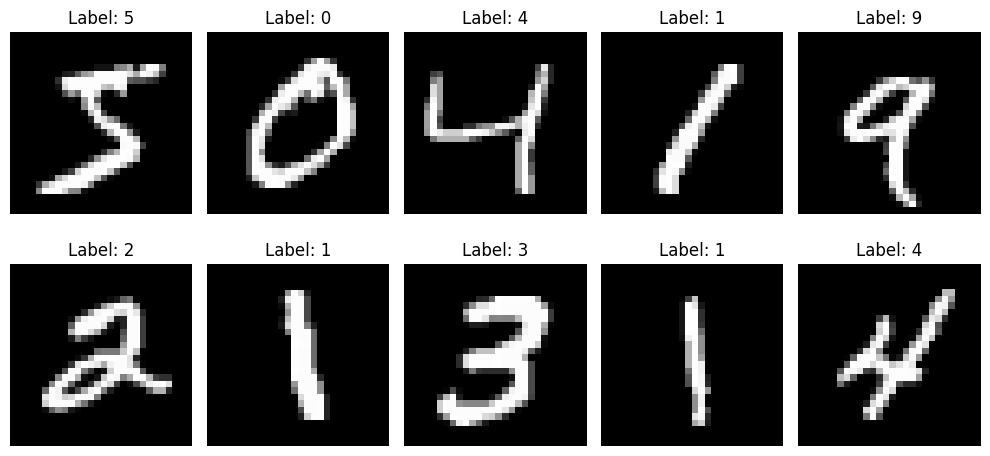

In [11]:
plt.figure(figsize=(10, 5))

for i in range(10):
    image = train_data.iloc[i, 1:].values.reshape(28, 28)
    label = train_data.iloc[i, 0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 7.5 Visualize random images

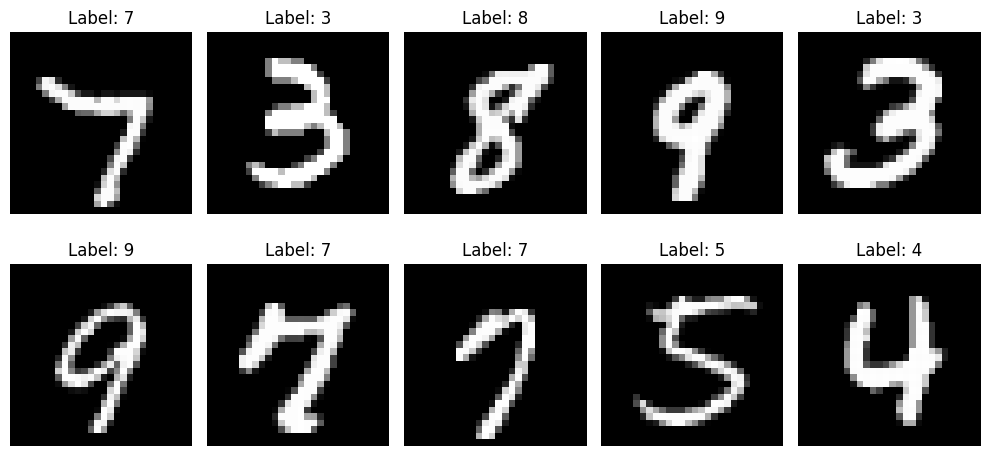

In [12]:
np.random.seed(42)

random_indices = np.random.choice(len(train_data), 10, replace=False)

plt.figure(figsize=(10, 5))

for i, index in enumerate(random_indices):
    image = train_data.iloc[index, 1:].values.reshape(28, 28)
    label = train_data.iloc[index, 0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Preprocess the dataset

### 8.1 Seperate features and labels

In [13]:
# Separate labels and pixel values

y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


### 8.2 Convert to numpy

In [14]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

y_train = np.asarray(y_train, dtype=np.int64)
y_test = np.asarray(y_test, dtype=np.int64)

print("X_train data type:", X_train.dtype)
print("y_train data type:", y_train.dtype)

X_train data type: float32
y_train data type: int64


### 8.3 Normalize pixel values

In [15]:
# Normalize pixel values from [0, 255] to [0, 1]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum training pixel value:", X_train.min())
print("Maximum training pixel value:", X_train.max())

Minimum training pixel value: 0.0
Maximum training pixel value: 1.0


### 8.4 One-Hot encode the labels

In [16]:
def one_hot_encode(y, num_classes=10):
    encoded = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    encoded[np.arange(y.shape[0]), y] = 1.0
    return encoded

In [17]:
y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)

print("Original label:", y_train[0])
print("Encoded label:", y_train_encoded[0])

Original label: 5
Encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 8.5 Verify the preprocessed dataset

In [18]:
print("X_train:", X_train.shape)
print("y_train:", y_train_encoded.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_encoded.shape)

print("\nPixel range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nExample:")
print("Original label:", y_train[0])
print("One-hot label :", y_train_encoded[0])

X_train: (60000, 784)
y_train: (60000, 10)
X_test : (10000, 784)
y_test : (10000, 10)

Pixel range:
Minimum: 0.0
Maximum: 1.0

Example:
Original label: 5
One-hot label : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 9. Activation function

### 9.1 ReLU
$$ReLU(x)=max(0,x)$$

In [19]:
def relu(x):
    return np.maximum(0, x)

### 9.2 ReLU Derivate
$$ReLU'(x) = \begin{cases} 0 & x \le 0 \\ 1 & x > 0 \end{cases}$$



In [20]:
def relu_derivative(x):
    return (x > 0).astype(np.float32)

### 9.3 Softmax
$$Softmax(z)_i = \frac{e^{z_i - \max(z)}}{\sum_{j} e^{z_j - \max(z)}}$$

In [21]:
def softmax(x):
    exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

## 10. Parameter Initialization

### 10.1 Understanding the weight dimensions


#### First Layer

784 input neurons -> 128 hidden neurons

$$W_1=(784,128)$$

#### Second Layer

128 nuerons -> 64 neurons

$$W_2=(128,64)$$

#### Third Layer

64 nuerons -> 10 output nuerons

$$W_3=(64,10)$$

### 10.2 Random Weigths?

If every weight started at zero, nuerons in the same layer would behave identically and learn the same thing.

Therefore, we start with small random values.

We'll use He initialization, which is suitable for layers using ReLU.

$$W=\sqrt{\frac{2}{n_{in}}}×random$$

where $n_{in}$ is the number of inputs to the layer.

### 10.3 Initialize the Parameters

In [22]:
# Set random seed for reproducibility
np.random.seed(42)

# Network architecture
input_size = 784
hidden1_size = 128
hidden2_size = 64
output_size = 10

# He initialization for weights
W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(2 / hidden2_size)

# Biases initialized to zero
b1 = np.zeros((1, hidden1_size))
b2 = np.zeros((1, hidden2_size))
b3 = np.zeros((1, output_size))

### 10.4 Check the Shapes

In [23]:
print("Weight and bias shapes:")
print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape)

print("W3:", W3.shape)
print("b3:", b3.shape)

Weight and bias shapes:
W1: (784, 128)
b1: (1, 128)
W2: (128, 64)
b2: (1, 64)
W3: (64, 10)
b3: (1, 10)


### 10.5 Why Are Biases (1, neurons)?

$$Z_1​=XW_1​+b_1​$$

here we have,    
X  → (64, 784)   
W1 → (784, 128)

therefore,   
X @ W1 → (64, 128)

then,  
b1 → (1, 128)



### 10.6 Inspect the Initialized Weights

In [24]:
print("W1 mean:", W1.mean())
print("W1 std :", W1.std())

print("\nW2 mean:", W2.mean())
print("W2 std :", W2.std())

print("\nW3 mean:", W3.mean())
print("W3 std :", W3.std())

W1 mean: 4.32564733577339e-05
W1 std : 0.05055087515920159

W2 mean: 0.001442031078883276
W2 std : 0.12464375038283954

W3 mean: 0.007116514178006942
W3 std : 0.17235948925396494


## 11. Forward Propagation

Forward propagation is the process of passing input data through the neural network to generate predictions.

The following operations are performed:

1. The input is multiplied by the first weight matrix and the first bias is added.
2. ReLU activation is applied to the first hidden layer.
3. The result is passed through the second hidden layer and ReLU activation.
4. The output layer produces 10 logits.
5. Softmax converts the logits into probabilities for the ten digit classes.

The forward propagation equations are:

$$Z_1 = XW_1 + b_1$$

$$A_1 = \text{ReLU}(Z_1)$$

$$Z_2 = A_1W_2 + b_2$$

$$A_2 = \text{ReLU}(Z_2)$$

$$Z_3 = A_2W_3 + b_3$$

$$\hat{Y} = \text{Softmax}(Z_3)$$

In [25]:
def forward_pass(X):
    # First hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Second hidden layer
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

### Testing the Forward Propogation

In [26]:
# Test forward propagation with one mini-batch

X_sample = X_train[:64]
y_sample = y_train_encoded[:64]

Z1, A1, Z2, A2, Z3, predictions = forward_pass(X_sample)

print("Input shape       :", X_sample.shape)
print("Z1 shape          :", Z1.shape)
print("A1 shape          :", A1.shape)
print("Z2 shape          :", Z2.shape)
print("A2 shape          :", A2.shape)
print("Z3 shape          :", Z3.shape)
print("Output shape      :", predictions.shape)

Input shape       : (64, 784)
Z1 shape          : (64, 128)
A1 shape          : (64, 128)
Z2 shape          : (64, 64)
A2 shape          : (64, 64)
Z3 shape          : (64, 10)
Output shape      : (64, 10)


In [27]:
print("First image probabilities:")
print(predictions[0])

print("\nSum of probabilities:")
print(np.sum(predictions[0]))

print("\nPredicted digit:")
print(np.argmax(predictions[0]))

print("Actual digit:")
print(y_train[0])

print("\nprediction is wrong because we have random weights initialized but not modified in this stage")

First image probabilities:
[0.09388061 0.10909534 0.08844146 0.16733248 0.08594549 0.14369977
 0.0870043  0.06717489 0.08199478 0.07543089]

Sum of probabilities:
1.0

Predicted digit:
3
Actual digit:
5

prediction is wrong because we have random weights initialized but not modified in this stage


## 12. Loss Function

Cross-entropy loss is used to measure the difference between the actual class labels and the probabilities predicted by the neural network.

For a single sample, the categorical cross-entropy loss is:

$$L = -\sum_{i} y_i \log(\hat{y}_i)$$

For a batch of m samples, the average loss is:

$$L = -\frac{1}{m} \sum_{i} \sum_{j} y_{i,j} \log(\hat{y}_{i,j})$$

A smaller loss indicates that the predicted probabilities are closer to the actual class labels.

In [28]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

    return loss

### Testing the loss function

In [29]:
loss = cross_entropy_loss(y_sample, predictions)

print("Initial Loss:", loss)

print("\nthe loss is likely around the above before training because the network is randomly initialized.")

Initial Loss: 2.4518817735965044

the loss is likely around the above before training because the network is randomly initialized.


## 13. Backpropagation

Backpropagation calculates how much each weight and bias contributed to the prediction error.

The gradients are calculated by applying the chain rule from the output layer back toward the input layer.

For the Softmax output combined with cross-entropy loss:

$$dZ_3 = A_3 - Y$$

The gradients for the output layer are:

$$dW_3 = A_2^T dZ_3$$

$$db_3 = \sum dZ_3$$

The gradient is then propagated to the second hidden layer:

$$dA_2 = dZ_3 W_3^T$$

$$dZ_2 = dA_2 \odot \text{ReLU}'(Z_2)$$

Similarly, for the first hidden layer:

$$dA_1 = dZ_2 W_2^T$$

$$dZ_1 = dA_1 \odot \text{ReLU}'(Z_1)$$

Finally:

$$dW_2 = A_1^T dZ_2$$

$$db_2 = \sum dZ_2$$

$$dW_1 = X^T dZ_1$$

$$db_1 = \sum dZ_1$$

In [30]:
def backward_pass(X, y_true, Z1, A1, Z2, A2, Z3, A3):
    m = X.shape[0]

    # Output layer gradients
    dZ3 = A3 - y_true
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Second hidden layer gradients
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # First hidden layer gradients
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

### Testing backpropogation

In [31]:
dW1, db1, dW2, db2, dW3, db3 = backward_pass(
    X_sample,
    y_sample,
    Z1,
    A1,
    Z2,
    A2,
    Z3,
    predictions
)

print("Gradient shapes:")
print("dW1:", dW1.shape)
print("db1:", db1.shape)
print("dW2:", dW2.shape)
print("db2:", db2.shape)
print("dW3:", dW3.shape)
print("db3:", db3.shape)

Gradient shapes:
dW1: (784, 128)
db1: (1, 128)
dW2: (128, 64)
db2: (1, 64)
dW3: (64, 10)
db3: (1, 10)


## 14. Gradient Descent

Gradient descent updates the weights and biases using the gradients calculated during backpropagation.

The parameter update rule is:

$$\theta_{\text{new}} = \theta_{\text{old}} - \eta \frac{\partial L}{\partial \theta}$$

where:

- $θ$ epresents a weight or bias parameter.
- $η$ is the learning rate.
- $\frac{∂L}{∂θ}$ is the gradient of the loss with respect to that parameter.

The learning rate controls the size of each parameter update.

In [32]:
def update_parameters(dW1, db1, dW2, db2, dW3, db3, learning_rate):
    global W1, b1, W2, b2, W3, b3

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

## 15. Model Training

The neural network is trained using mini-batch gradient descent.

During each epoch:

1. The training data is shuffled.
2. The data is divided into mini-batches.
3. Forward propagation generates predictions.
4. Cross-entropy loss is calculated.
5. Backpropagation calculates the gradients.
6. Gradient descent updates the weights and biases.

The training loss and accuracy are recorded after each epoch.

In [33]:
def calculate_accuracy(y_true, y_pred):
    true_labels = np.argmax(y_true, axis=1)
    predicted_labels = np.argmax(y_pred, axis=1)

    return np.mean(true_labels == predicted_labels)

In [34]:
def train(X, y, epochs=10, batch_size=64, learning_rate=0.01):
    loss_history = []
    accuracy_history = []

    n_samples = X.shape[0]

    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_loss = 0.0

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Forward propagation
            Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch)

            # Loss
            loss = cross_entropy_loss(y_batch, A3)
            epoch_loss += loss * X_batch.shape[0]

            # Backpropagation
            gradients = backward_pass(
                X_batch,
                y_batch,
                Z1,
                A1,
                Z2,
                A2,
                Z3,
                A3
            )

            # Gradient descent
            update_parameters(*gradients, learning_rate)

        # Average epoch loss
        epoch_loss /= n_samples

        # Calculate training accuracy
        _, _, _, _, _, train_predictions = forward_pass(X)
        epoch_accuracy = calculate_accuracy(y, train_predictions)

        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {epoch_loss:.4f} "
            f"- Accuracy: {epoch_accuracy:.4f}"
        )

    return loss_history, accuracy_history

### Training the network

In [35]:
loss_history, accuracy_history = train(
    X_train,
    y_train_encoded,
    epochs=10,
    batch_size=64,
    learning_rate=0.01
)

Epoch 1/10 - Loss: 0.7958 - Accuracy: 0.8852
Epoch 2/10 - Loss: 0.3600 - Accuracy: 0.9088
Epoch 3/10 - Loss: 0.2995 - Accuracy: 0.9203
Epoch 4/10 - Loss: 0.2640 - Accuracy: 0.9295
Epoch 5/10 - Loss: 0.2386 - Accuracy: 0.9360
Epoch 6/10 - Loss: 0.2180 - Accuracy: 0.9419
Epoch 7/10 - Loss: 0.2014 - Accuracy: 0.9473
Epoch 8/10 - Loss: 0.1874 - Accuracy: 0.9507
Epoch 9/10 - Loss: 0.1749 - Accuracy: 0.9532
Epoch 10/10 - Loss: 0.1643 - Accuracy: 0.9556


## 16. Model Evaluation

After training, the neural network is evaluated using the 10,000 MNIST test images.

The test dataset is not used during training. Therefore, its accuracy provides an estimate of how well the trained neural network generalizes to unseen handwritten digits.

In [36]:
# Generate predictions for the test dataset
_, _, _, _, _, test_predictions = forward_pass(X_test)

# Calculate test loss
test_loss = cross_entropy_loss(y_test_encoded, test_predictions)

# Calculate test accuracy
test_accuracy = calculate_accuracy(y_test_encoded, test_predictions)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1607
Test Accuracy: 95.29%


## 17. Visualization

The training loss and accuracy are visualized to understand how the neural network learns over successive epochs.

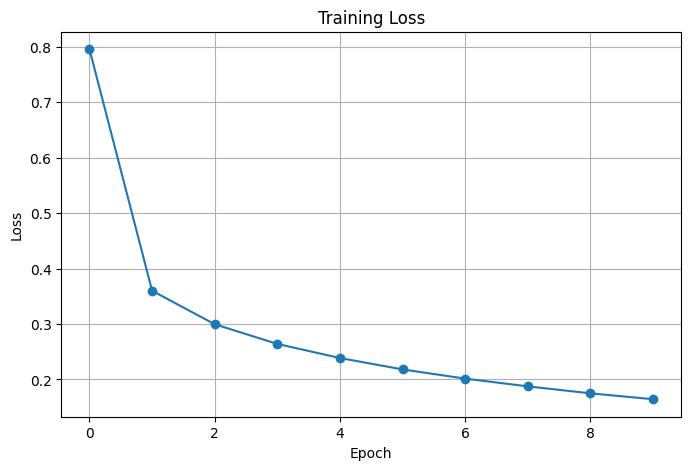

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

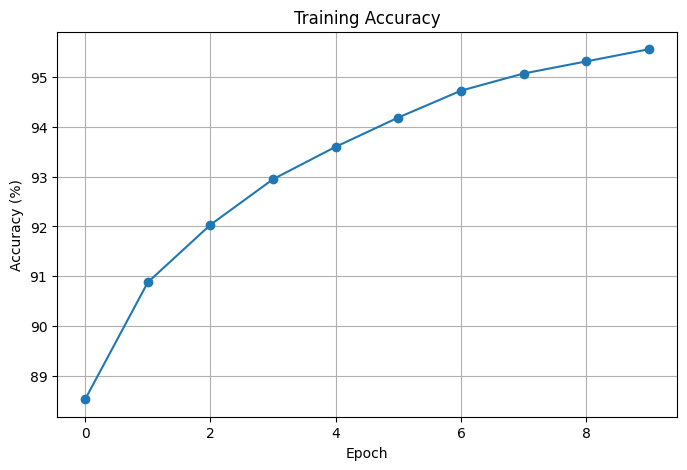

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(accuracy_history) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid(True)
plt.show()

## 18. Sample Predictions

A set of test images is displayed along with the digit predicted by the trained neural network and the actual digit label.

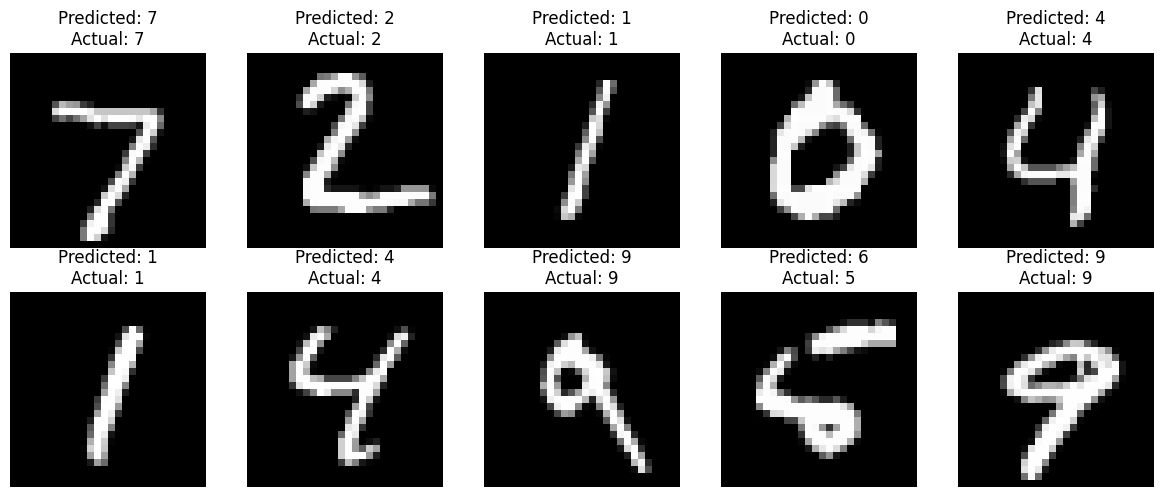

In [39]:
num_samples = 10

plt.figure(figsize=(12, 5))

for i in range(num_samples):
    image = X_test[i].reshape(28, 28)

    predicted_digit = np.argmax(test_predictions[i])
    actual_digit = y_test[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Predicted: {predicted_digit}\nActual: {actual_digit}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 19. Results and Discussion

The feedforward neural network was successfully implemented from scratch using NumPy. The network consists of an input layer with 784 neurons, two hidden layers containing 128 and 64 neurons, and an output layer containing 10 neurons.

ReLU activation was used in the hidden layers and Softmax activation was used in the output layer. Categorical cross-entropy was used as the loss function, while mini-batch gradient descent was used to optimize the network parameters.

The model was trained using the complete MNIST training dataset containing 60,000 images and evaluated using the 10,000-image test dataset.

The training loss decreased over the epochs, while the training accuracy increased, indicating that the neural network learned useful patterns from the handwritten digit images.

### Conclusion

The experiment demonstrates the fundamental working of a feedforward neural network without relying on built-in deep learning frameworks. Forward propagation, activation functions, loss calculation, backpropagation, gradient calculation, and gradient descent were implemented manually.

The trained network was able to classify handwritten digits from the MNIST dataset and achieve a satisfactory classification accuracy on unseen test images.

## Images To Save

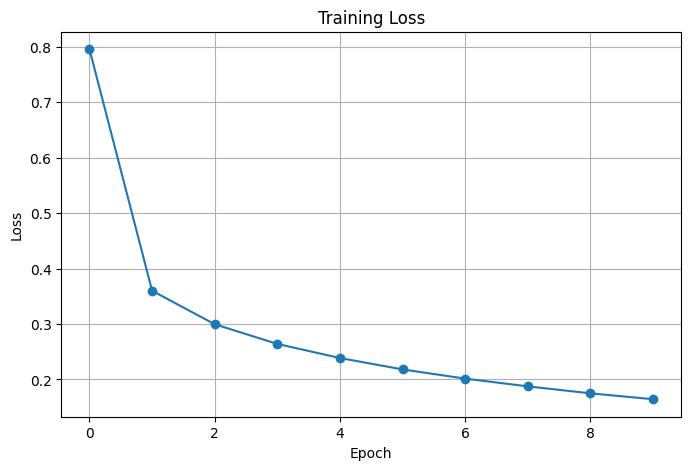

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.savefig("loss_graph.png", dpi=300, bbox_inches="tight")
plt.show()

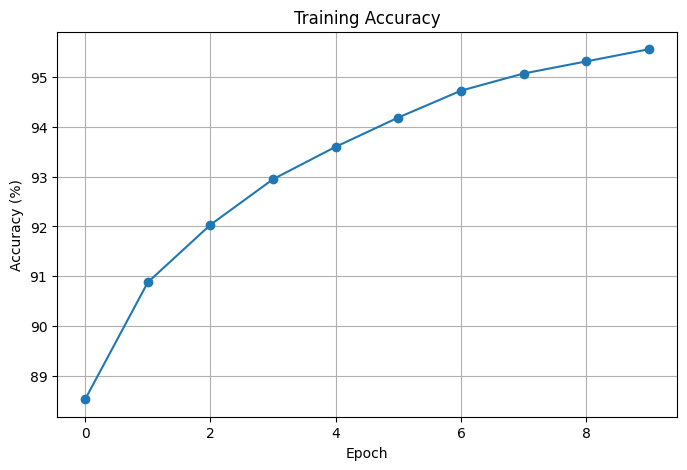

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(accuracy_history) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")
plt.grid(True)

plt.savefig("accuracy_graph.png", dpi=300, bbox_inches="tight")
plt.show()

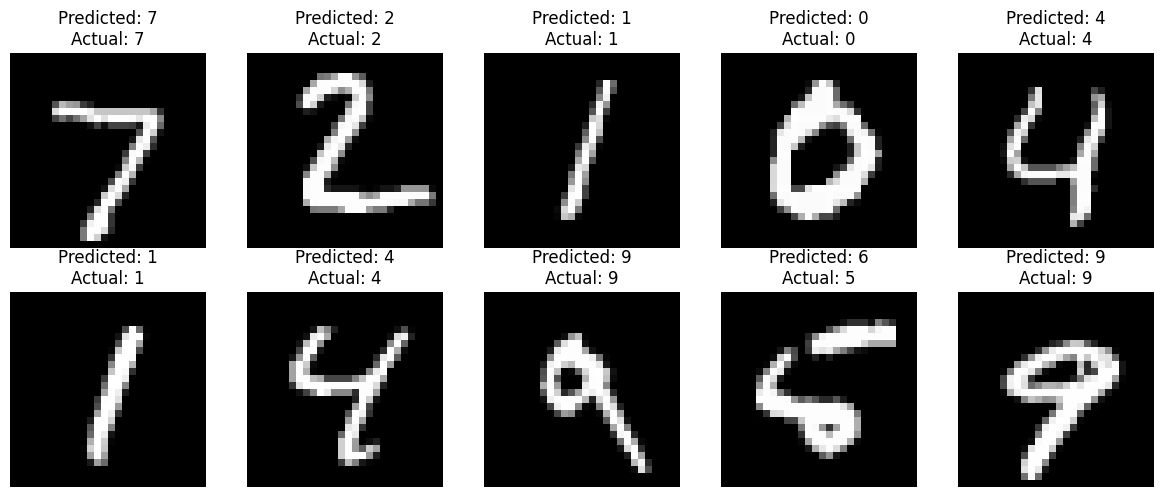

In [42]:
num_samples = 10

plt.figure(figsize=(12, 5))

for i in range(num_samples):
    image = X_test[i].reshape(28, 28)

    predicted_digit = np.argmax(test_predictions[i])
    actual_digit = y_test[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Predicted: {predicted_digit}\nActual: {actual_digit}"
    )
    plt.axis("off")

plt.tight_layout()

plt.savefig("predictions.png", dpi=300, bbox_inches="tight")
plt.show()

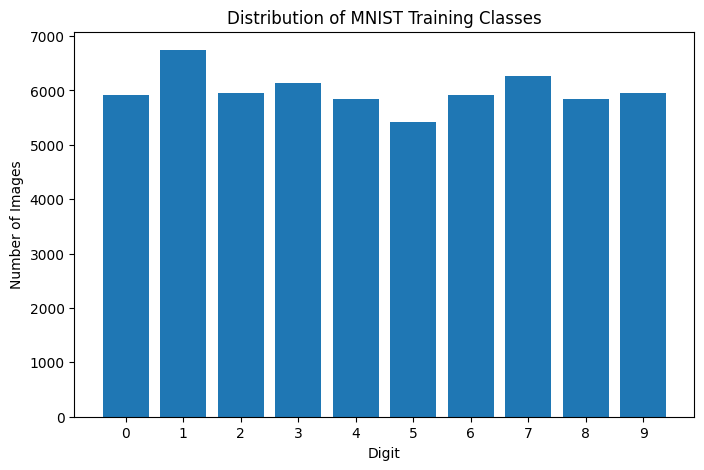

In [43]:
label_counts = train_data.iloc[:, 0].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Distribution of MNIST Training Classes")
plt.xticks(range(10))

plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()